In [6]:
debate_arguments <- data.frame(
  Argument_ID = c("A001", "A002", "A003", "A004", "A005", "A006"),
  Position = c("For", "For", "For", "Against", "Against", "Against"),
  Topic = c("Learning", "Productivity", "AI Literacy", "Academic Integrity", "Dependency", "Assessment"),
  Claim = c(
    "AI can provide students with immediate learning support.",
    "AI can help students complete routine academic tasks more efficiently.",
    "Allowing AI use can help students develop AI literacy.",
    "Undisclosed AI-generated work may create academic integrity concerns.",
    "Excessive AI use may reduce students' independent problem-solving practice.",
    "AI use may make it more difficult to determine whether submitted work reflects student learning."
  )
)
debate_arguments

Argument_ID,Position,Topic,Claim
<chr>,<chr>,<chr>,<chr>
A001,For,Learning,AI can provide students with immediate learning support.
A002,For,Productivity,AI can help students complete routine academic tasks more efficiently.
A003,For,AI Literacy,Allowing AI use can help students develop AI literacy.
A004,Against,Academic Integrity,Undisclosed AI-generated work may create academic integrity concerns.
A005,Against,Dependency,Excessive AI use may reduce students' independent problem-solving practice.
A006,Against,Assessment,AI use may make it more difficult to determine whether submitted work reflects student learning.


In [17]:
evidence_data <- data.frame(
  Evidence_ID = c("E001", "E002", "E003", "E004", "E005", "E006"),
  Argument_ID = c("A001", "A002", "A003", "A004", "A005", "A006"),
  Evidence_Type = c("Research", "Research", "Policy", "Policy", "Research", "Research"),
  Strength = c("Strong", "Moderate", "Strong", "Strong", "Moderate", "Strong"),
  stringsAsFactors = FALSE
)
evidence_data

Evidence_ID,Argument_ID,Evidence_Type,Strength
<chr>,<chr>,<chr>,<chr>
E001,A001,Research,Strong
E002,A002,Research,Moderate
E003,A003,Policy,Strong
E004,A004,Policy,Strong
E005,A005,Research,Moderate
E006,A006,Research,Strong


In [13]:
table(debate_arguments$Position)


Against     For 
      3       3 

In [14]:
nrow(debate_arguments)

[1] 6

In [18]:
table(evidence_data$Strength)


Moderate   Strong 
       2        4 

In [19]:
nrow(evidence_data)

[1] 6

In [23]:
Knowledge_Base <- merge(
  debate_arguments,
  evidence_data,
  by = "Argument_ID"
)

print(Knowledge_Base)

  Argument_ID Position              Topic
1        A001      For           Learning
2        A002      For       Productivity
3        A003      For        AI Literacy
4        A004  Against Academic Integrity
5        A005  Against         Dependency
6        A006  Against         Assessment
                                                                                             Claim
1                                         AI can provide students with immediate learning support.
2                           AI can help students complete routine academic tasks more efficiently.
3                                           Allowing AI use can help students develop AI literacy.
4                            Undisclosed AI-generated work may create academic integrity concerns.
5                      Excessive AI use may reduce students' independent problem-solving practice.
6 AI use may make it more difficult to determine whether submitted work reflects student learning.
  Evidence_ID

In [27]:
Get_Score <- function(Strength){
  if (Strength == "Strong"){
    return(3)
  }else if(Strength == "Moderate"){
    return(2)
  }else if (Strength == "Weak"){
    return(1)
  }else {
    return(0)
  }
}

Get_Score("Strong")
Get_Score("Moderate")
Get_Score("Weak")
Get_Score("N/A")


[1] 3

[1] 2

[1] 1

[1] 0

In [26]:
Knowledge_Base$Evidence_Score <- sapply(
  Knowledge_Base$Strength,
  Get_Score
)
print(Knowledge_Base)

  Argument_ID Position              Topic
1        A001      For           Learning
2        A002      For       Productivity
3        A003      For        AI Literacy
4        A004  Against Academic Integrity
5        A005  Against         Dependency
6        A006  Against         Assessment
                                                                                             Claim
1                                         AI can provide students with immediate learning support.
2                           AI can help students complete routine academic tasks more efficiently.
3                                           Allowing AI use can help students develop AI literacy.
4                            Undisclosed AI-generated work may create academic integrity concerns.
5                      Excessive AI use may reduce students' independent problem-solving practice.
6 AI use may make it more difficult to determine whether submitted work reflects student learning.
  Evidence_ID

In [30]:
Classify_Support <- function(Evidence_Score){
  if (Evidence_Score == 3){
    return("Strongly support")
  }else if (Evidence_Score == 2){
    return("Moderately support")
  }else if (Evidence_Score == 1){
    return("Weakly support")
  }else{
    return("No support")
  }
}
Classify_Support(1)

[1] "Weakly support"

In [37]:
Knowledge_Base$Support_Level <- sapply(
  Knowledge_Base$Evidence_Score,
  Classify_Support
)

print(Knowledge_Base)

  Argument_ID Position              Topic
1        A001      For           Learning
2        A002      For       Productivity
3        A003      For        AI Literacy
4        A004  Against Academic Integrity
5        A005  Against         Dependency
6        A006  Against         Assessment
                                                                                             Claim
1                                         AI can provide students with immediate learning support.
2                           AI can help students complete routine academic tasks more efficiently.
3                                           Allowing AI use can help students develop AI literacy.
4                            Undisclosed AI-generated work may create academic integrity concerns.
5                      Excessive AI use may reduce students' independent problem-solving practice.
6 AI use may make it more difficult to determine whether submitted work reflects student learning.
  Evidence_ID

In [36]:
Search_Topic <- function(topic){
  Result <- subset(
    Knowledge_Base,
    Topic == topic
  )
  if (nrow (Result) == 0){
    cat("Topic not found")
  } else {
    print (Result)
  }
}

  Argument_ID Position    Topic
1        A001      For Learning
                                                     Claim Evidence_ID
1 AI can provide students with immediate learning support.        E001
  Evidence_Type Strength Evidence_Score    Support_Level
1      Research   Strong              3 Strongly support

Against     For 
      4       4 
 Argument_ID Position              Topic Strength      Support_Level
        A001      For           Learning   Strong   Strongly support
        A002      For       Productivity Moderate Moderately support
        A003      For        AI Literacy   Strong   Strongly support
        A004  Against Academic Integrity   Strong   Strongly support
        A005  Against         Dependency Moderate Moderately support
        A006  Against         Assessment   Strong   Strongly support
        A007      For    Personalization     Weak     Weakly support
        A008  Against       Data Privacy   Strong   Strongly support


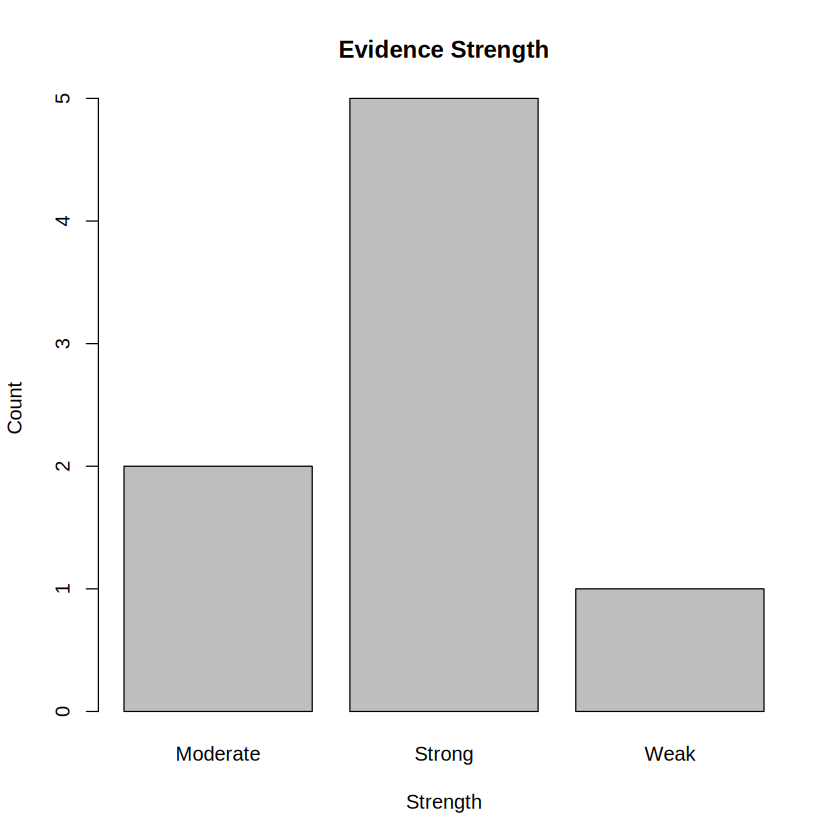

In [39]:
Get_Score <- function(Strength) {
  if (Strength == "Strong") return(3)
  if (Strength == "Moderate") return(2)
  if (Strength == "Weak") return(1)
  return(0)
}

Classify_Support <- function(Evidence_Score) {
  if (Evidence_Score == 3) return("Strongly support")
  if (Evidence_Score == 2) return("Moderately support")
  if (Evidence_Score == 1) return("Weakly support")
  return("No support")
}

debate_arguments <- data.frame(
  Argument_ID = c("A001", "A002", "A003", "A004", "A005", "A006", "A007", "A008"),
  Position = c("For", "For", "For", "Against", "Against", "Against", "For", "Against"),
  Topic = c("Learning", "Productivity", "AI Literacy", "Academic Integrity",
            "Dependency", "Assessment", "Personalization", "Data Privacy"),
  Claim = c(
    "AI can provide students with immediate learning support.",
    "AI can help students complete routine academic tasks more efficiently.",
    "Allowing AI use can help students develop AI literacy.",
    "Undisclosed AI-generated work may create academic integrity concerns.",
    "Excessive AI use may reduce students' independent problem-solving practice.",
    "AI use may make it more difficult to determine whether submitted work reflects student learning.",
    "AI tools adapt to individual student learning speeds.",
    "Student data submitted to public AI models poses privacy risks."
  ),
  stringsAsFactors = FALSE
)

evidence_data <- data.frame(
  Evidence_ID = c("E001", "E002", "E003", "E004", "E005", "E006", "E007", "E008"),
  Argument_ID = c("A001", "A002", "A003", "A004", "A005", "A006", "A007", "A008"),
  Evidence_Type = c("Research", "Research", "Policy", "Policy", "Research", "Research", "Research", "Policy"),
  Strength = c("Strong", "Moderate", "Strong", "Strong", "Moderate", "Strong", "Weak", "Strong"),
  stringsAsFactors = FALSE
)

build_knowledge_base <- function(args, ev_data) {
  kb <- merge(args, ev_data, by = "Argument_ID")
  kb$Evidence_Score <- sapply(kb$Strength, Get_Score)
  kb$Support_Level <- sapply(kb$Evidence_Score, Classify_Support)
  return(kb)
}

Knowledge_Base <- build_knowledge_base(debate_arguments, evidence_data)

Search_Topic <- function(topic, kb = Knowledge_Base) {
  Result <- subset(kb, grepl(topic, Topic, ignore.case = TRUE))
  if (nrow(Result) == 0) {
    cat("Topic not found\n")
  } else {
    print(Result)
  }
}

visualize_evidence_strength <- function(kb = Knowledge_Base) {
  counts <- table(kb$Strength)
  barplot(counts, main = "Evidence Strength", xlab = "Strength", ylab = "Count")
}

generate_debate_report <- function(kb = Knowledge_Base) {
  print(table(kb$Position))
  print(kb[, c("Argument_ID", "Position", "Topic", "Strength", "Support_Level")], row.names = FALSE)
}

Search_Topic("Learning")
generate_debate_report()
visualize_evidence_strength()